# Data Mining - Part 2  
Authors: Bezalel Spolter and Eden Philosoph

# General

Imports

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score, precision_score, make_scorer, log_loss
from sklearn.model_selection import train_test_split, ParameterGrid, cross_val_score, KFold, ParameterSampler, cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

%matplotlib inline
sns.set(color_codes=True) 
sns.set(rc={'figure.figsize':(5,5)}) 

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


Reading Files

In [41]:
data_df = pd.read_csv('cleaned_churn_dataset_train.csv')
test = pd.read_csv('cleaned_churn_dataset_test.csv')

In [42]:
data_df.columns

Index(['customer_id', 'Name', 'age', 'gender', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'preferred_offer_types', 'medium_of_operation', 'internet_option',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn', 'feedback_kind'],
      dtype='object')

Changing joining_date column to number rather than date

In [43]:
data_df['joining_date'] = pd.to_datetime(data_df['joining_date'], errors='coerce')
reference_date = pd.Timestamp('2018-01-01')
data_df['days_since_joined'] = (reference_date - data_df['joining_date']).dt.days

In [44]:
data_df['days_since_joined'].describe()

count    24365.000000
mean       546.048594
std        317.956331
min          1.000000
25%        270.000000
50%        545.000000
75%        822.000000
max       1096.000000
Name: days_since_joined, dtype: float64

We are deleting all columns with singular values - customer_id, Name, joining_date <br>
The classifying algorithms don't get value from those columns. They don't help classifying

In [45]:
data_df = data_df.drop(columns=['Name','joining_date', 'customer_id']).copy()
data_df.columns

Index(['age', 'gender', 'region_category', 'membership_category',
       'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn', 'feedback_kind', 'days_since_joined'],
      dtype='object')

Doing the same to test dataset - changing joining_date to number of days since January 1st, 2018 and then deleting unique columns Name and joining_date

In [46]:
test.columns

Index(['Name', 'age', 'gender', 'region_category', 'membership_category',
       'joining_date', 'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'feedback_kind'],
      dtype='object')

In [47]:
test['joining_date'] = pd.to_datetime(test['joining_date'], errors='coerce')
reference_date = pd.Timestamp('2018-01-01')
test['days_since_joined'] = (reference_date - test['joining_date']).dt.days

In [48]:
test['days_since_joined'].describe()

count    12208.000000
mean       544.937009
std        317.517599
min          1.000000
25%        268.000000
50%        544.000000
75%        826.000000
max       1096.000000
Name: days_since_joined, dtype: float64

In [49]:
test = test.drop(columns=['Name','joining_date']).copy()
test.columns

Index(['age', 'gender', 'region_category', 'membership_category',
       'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'feedback_kind', 'days_since_joined'],
      dtype='object')

In [50]:
categorical_columns = data_df.select_dtypes(include='object').columns
numerical_columns = data_df.select_dtypes(exclude='object').columns
numerical_columns = numerical_columns.drop('churn')

In [51]:
print(categorical_columns)
print(numerical_columns)

Index(['gender', 'region_category', 'membership_category',
       'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'feedback_kind'],
      dtype='object')
Index(['age', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'days_since_joined'],
      dtype='object')


Normalizing all Numerical columns

In [52]:
scaler = MinMaxScaler()
data_df[numerical_columns] = scaler.fit_transform(data_df[numerical_columns])
data_df[numerical_columns].describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,days_since_joined
count,24365.000000,24365.000000,24365.000000,24365.000000,24365.000000,24365.000000,24365.000000
mean,0.499717,0.468766,0.099507,0.287561,0.245059,0.345781,0.497761
std,0.293625,0.222936,0.112818,0.196201,0.125539,0.145574,0.290371
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.240741,0.320000,0.020964,0.134993,0.149036,0.319450,0.245662
50%,0.500000,0.480000,0.057347,0.270459,0.238513,0.375143,0.496804
75%,0.759259,0.640000,0.132732,0.404071,0.342903,0.416531,0.749772
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [53]:
test[numerical_columns] = scaler.transform(test[numerical_columns])
test[numerical_columns].describe()  

,age,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,days_since_joined
count,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000,12208.000000
mean,0.507120,0.472933,0.100878,0.286515,0.244598,0.343174,0.496746
std,0.294043,0.222554,0.115896,0.196355,0.124579,0.150142,0.289970
min,0.000000,0.000000,-0.003468,0.000039,0.000361,0.000000,0.000000
25%,0.259259,0.320000,0.020724,0.134622,0.149036,0.314198,0.243836
50%,0.518519,0.480000,0.057653,0.268541,0.238513,0.374601,0.495890
75%,0.759259,0.640000,0.134584,0.403850,0.342903,0.417665,0.753425
max,1.000000,1.000000,1.064453,0.998270,1.089471,1.138770,1.000000


Doing one-hot encoding to categorical columns

In [54]:
X = data_df.drop(columns=['churn']).copy()
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
X_encoded.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,days_since_joined,gender_Male,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,medium_of_operation_Unknown,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Solved,complaint_status_Unknown,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,feedback_kind_Positive,feedback_kind_Unknown
0,0.370370,0.76,0.035023,0.098666,0.357816,0.335929,0.131507,False,False,True,False,True,False,False,False,True,True,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,0.833333,0.56,0.055178,0.223608,0.402555,0.382320,0.631050,True,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,0.685185,0.88,0.009871,0.320884,0.253426,0.286538,0.185388,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,0.148148,0.24,0.338002,0.485434,0.402555,0.632986,0.631050,True,True,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,0.333333,0.36,0.144459,0.193814,0.208687,0.359419,0.153425,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,True


In [55]:
test = pd.get_dummies(test, columns=categorical_columns, drop_first=True)
test.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,days_since_joined,gender_Male,region_category_Town,region_category_Village,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership,joined_through_referral_Yes,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers,medium_of_operation_Desktop,medium_of_operation_Smartphone,medium_of_operation_Unknown,internet_option_Mobile_Data,internet_option_Wi-Fi,used_special_discount_Yes,offer_application_preference_Yes,past_complaint_Yes,complaint_status_Solved,complaint_status_Unknown,complaint_status_Unsolved,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website,feedback_kind_Positive,feedback_kind_Unknown
0,0.074074,0.20,0.006302,0.238571,0.119210,0.000000,0.107763,False,True,False,False,False,False,False,True,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,0.129630,0.32,0.239470,0.239641,0.089384,0.175050,0.470320,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,True,True,False,False,False,False,True,False,False,False,False,False,False,False
2,0.537037,0.28,0.133964,0.373698,0.238513,0.360387,0.374429,True,True,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0.444444,0.12,0.068166,0.010224,0.733190,0.316275,0.122374,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,0.703704,0.24,0.177536,0.151295,0.178862,0.000000,0.784475,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True


Making sure input is the same amount of columns for train and test

In [56]:
print(X_encoded.shape)
print(test.shape)

(24365, 39)
(12208, 39)


Setting Target Feature - Churn column

In [57]:
y = data_df['churn'].copy()

Splitting into train and test groups with train/test size 0.8/0.2 and keeping same ratio of churn for each group

In [58]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Model 1 - Random Forest

Steps:  
1. Hypertuning parameters - here 50 iterations of combinations of parameters was randomly chosen because run time is too long to try all the combinations.   Each model is trained using 5-fold Cross Validation and then performance measure is mean of those results  
2. Printing best results for each measure we want to maximize (as detailed in report)  
3. Printing top 5 accuracy models parameters
4. Plotting 5-fold CV train and test loss and Accuracy comparison to see that there is no overfitting
5. Plotting and extracting the top 10 most important features which helped the model classify

In [87]:

# =============================
# Configurable Parameters
# =============================
params = {
    "random_state": 42,
    "n_jobs": -1,
    "cv_folds": 5
}

# =============================
# Define Parameter Grid
# =============================
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}
results = []

n_iter_search = 50

# Randomly sample
param_combinations = list(ParameterSampler(
    param_grid,
    n_iter=n_iter_search,
    random_state=params["random_state"]
))

print(f"Running randomized search with {len(param_combinations)} random combinations and {params['cv_folds']}-fold cross-validation:")

# =============================
# K-Fold Cross-Validation
# =============================
cv = KFold(
    n_splits=params["cv_folds"],
    shuffle=True,
    random_state=params["random_state"]
)

# =============================
# Grid Search Loop: Track multiple metrics
# =============================
for combo in tqdm(param_combinations, desc="Grid Search Progress"):
    model = RandomForestClassifier(
        n_estimators=combo['n_estimators'],
        max_depth=combo['max_depth'],
        bootstrap=combo['bootstrap'],
        criterion=combo['criterion'],
        class_weight=combo['class_weight'],
        random_state=params["random_state"],
        n_jobs=params["n_jobs"]
    )

    scores_accuracy = cross_val_score(
        model,
        X_encoded, y,
        cv=cv,
        scoring='accuracy',
        n_jobs=params["n_jobs"]
    )

    scores_precision = cross_val_score(
        model,
        X_encoded, y,
        cv=cv,
        scoring='precision',
        n_jobs=params["n_jobs"]
    )

    scores_recall = cross_val_score(
        model,
        X_encoded, y,
        cv=cv,
        scoring='recall',
        n_jobs=params["n_jobs"]
    )

    results.append({
        'params': combo,
        'mean_cv_accuracy': scores_accuracy.mean(),
        'mean_cv_precision': scores_precision.mean(),
        'mean_cv_recall': scores_recall.mean()
    })

# =============================
# Find Best Combinations for Each Metric
# =============================
best_acc = max(results, key=lambda x: x['mean_cv_accuracy'])
best_precision = max(results, key=lambda x: x['mean_cv_precision'])
best_recall = max(results, key=lambda x: x['mean_cv_recall'])

print(f"\nBest Parameters (Accuracy): {best_acc['params']} | Accuracy: {best_acc['mean_cv_accuracy']:.4f}")
print(f"Best Parameters (Precision): {best_precision['params']} | Precision: {best_precision['mean_cv_precision']:.4f}")
print(f"Best Parameters (Recall): {best_recall['params']} | Recall: {best_recall['mean_cv_recall']:.4f}")


# =============================
# Train and Evaluate each Best Model
# =============================

for metric_name, best_result in zip(
    ['Accuracy', 'Precision', 'Recall'],
    [best_acc, best_precision, best_recall]
):
    print(f"\n========== {metric_name} MODEL ==========")
    best_model = RandomForestClassifier(
        **best_result['params'],
        random_state=params["random_state"],
        n_jobs=params["n_jobs"]
    )
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Running randomized search with 50 random combinations and 5-fold cross-validation:


Grid Search Progress:   0%|          | 0/50 [00:00<?, ?it/s]


Best Parameters (Accuracy): {'n_estimators': 400, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True} | Accuracy: 0.8662
Best Parameters (Precision): {'n_estimators': 300, 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': False} | Precision: 0.7194
Best Parameters (Recall): {'n_estimators': 200, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': False} | Recall: 0.9972

========== Accuracy MODEL ==========

Confusion Matrix:
 [[2963  615]
 [   1 1294]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.83      0.91      3578
           1       0.68      1.00      0.81      1295

    accuracy                           0.87      4873
   macro avg       0.84      0.91      0.86      4873
weighted avg       0.91      0.87      0.88      4873


========== Precision MODEL ==========

Confusion Matrix:
 [[3185  393]
 [ 303  992]]

Class

(Results analysis is in report of project)

In [92]:
# Sort the results by accuracy in descending order
sorted_results = sorted(results, key=lambda x: x['mean_cv_accuracy'], reverse=True)

# Print the top 5
print("Top 5 Parameter Sets by Accuracy:\n")
for i, res in enumerate(sorted_results[:5], 1):
    print(f"Rank {i}:")
    print(f"Accuracy: {res['mean_cv_accuracy']:.4f}")
    print(f"Params: {res['params']}\n")


Top 5 Parameter Sets by Accuracy:

Rank 1:
Accuracy: 0.8662
Params: {'n_estimators': 400, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}

Rank 2:
Accuracy: 0.8659
Params: {'n_estimators': 200, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': False}

Rank 3:
Accuracy: 0.8658
Params: {'n_estimators': 100, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': False}

Rank 4:
Accuracy: 0.8658
Params: {'n_estimators': 300, 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': False}

Rank 5:
Accuracy: 0.8657
Params: {'n_estimators': 200, 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced', 'bootstrap': True}




Train Acc: 0.8657 +/- 0.0014
Test Acc: 0.8641 +/- 0.0051
Train Log Loss: 0.2907 +/- 0.0014
Test Log Loss: 0.3068 +/- 0.0065


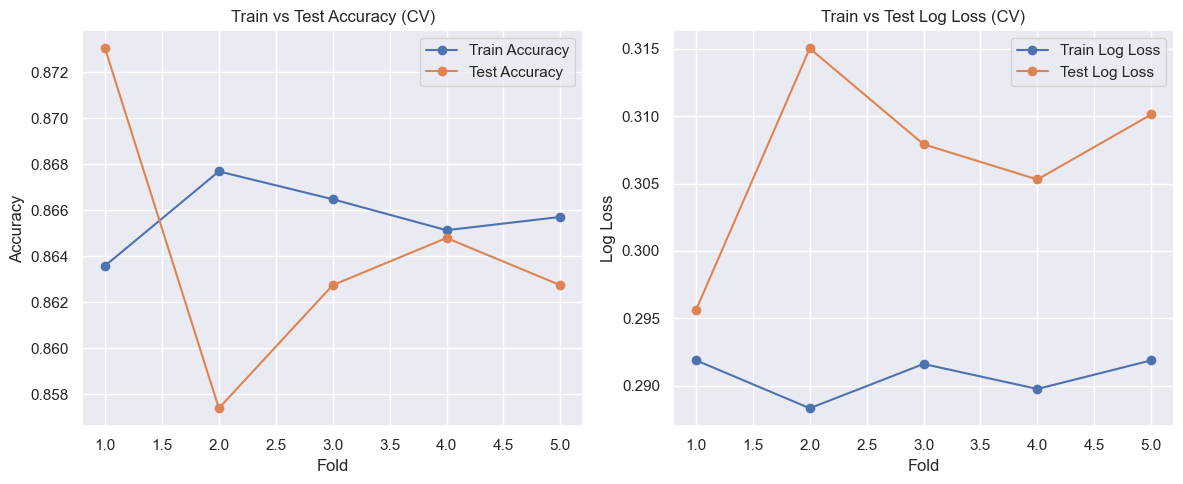


Top 10 Features:
points_in_wallet                           0.282575
membership_category_Gold Membership        0.178307
membership_category_Silver Membership      0.159666
membership_category_No Membership          0.092555
membership_category_Premium Membership     0.077651
membership_category_Platinum Membership    0.072012
feedback_kind_Positive                     0.051266
avg_transaction_value                      0.020554
feedback_Products always in Stock          0.009386
feedback_User Friendly Website             0.007363
dtype: float64


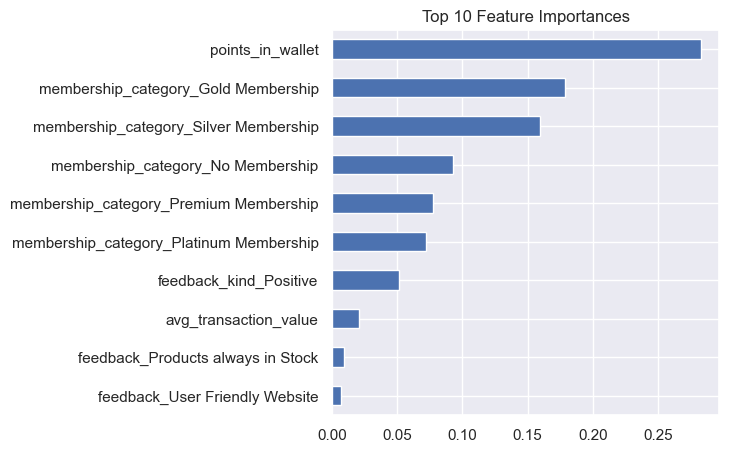

In [ ]:
# ================================
# 1. Best parameters from search
# ================================
best_params = {
    'n_estimators': 400,
    'max_depth': 10,
    'criterion': 'entropy',
    'class_weight': 'balanced',
    'bootstrap': True,
    'random_state': 42
}

# ================================
# 2. Create model
# ================================
rf = RandomForestClassifier(**best_params)

# ================================
# 3. 5-Fold CV: track accuracy & log loss
# ================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'neg_log_loss'],
    return_train_score=True
)

# ================================
# 4. CV results
# ================================
train_acc = cv_results['train_accuracy']
test_acc = cv_results['test_accuracy']
train_loss = -cv_results['train_neg_log_loss']
test_loss = -cv_results['test_neg_log_loss']

print(f"\nTrain Acc: {train_acc.mean():.4f} +/- {train_acc.std():.4f}")
print(f"Test Acc: {test_acc.mean():.4f} +/- {test_acc.std():.4f}")
print(f"Train Log Loss: {train_loss.mean():.4f} +/- {train_loss.std():.4f}")
print(f"Test Log Loss: {test_loss.mean():.4f} +/- {test_loss.std():.4f}")

# ================================
# 5. Plot Accuracy & Loss
# ================================
folds = range(1, 6)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(folds, train_acc, label='Train Accuracy', marker='o')
plt.plot(folds, test_acc, label='Test Accuracy', marker='o')
plt.title('Train vs Test Accuracy (CV)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()

# Log Loss plot
plt.subplot(1, 2, 2)
plt.plot(folds, train_loss, label='Train Log Loss', marker='o')
plt.plot(folds, test_loss, label='Test Log Loss', marker='o')
plt.title('Train vs Test Log Loss (CV)')
plt.xlabel('Fold')
plt.ylabel('Log Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ================================
# 6. Fit final model on full train set
# ================================
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# ================================
# 7. Feature importances: top 10
# ================================
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 10 Features:")
print(feature_importances.head(10))

feature_importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()


# Model 2 - Adaboost

Steps:  
1. Hypertuning parameters  
Each model is trained using 5-fold Cross Validation and then performance measure is mean of those results  
2. Printing best results only for Accuracy   
3. Printing top 5 accuracy models parameters
4. Plotting 5-fold CV train and test loss and Accuracy comparison to see that there is no overfitting

In [100]:

# =============================
# Expanded Parameter Grid
# =============================
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.001, 0.005],
}

param_combinations = list(ParameterGrid(param_grid))
results = []

print(f"Running full grid search with {len(param_combinations)} combinations and {params['cv_folds']}-fold CV...")

# =============================
# K-Fold Cross-Validation
# =============================
cv = KFold(
    n_splits=params["cv_folds"],
    shuffle=True,
    random_state=params["random_state"]
)

# =============================
# Grid Search Loop: Multiple Metrics
# =============================
for combo in tqdm(param_combinations, desc="Grid Search Progress"):
    model = AdaBoostClassifier(
        random_state=params["random_state"],
        **combo
    )

    scores_accuracy = cross_val_score(
        model, X_encoded, y,
        cv=cv,
        scoring='accuracy'
    )

    results.append({
        'params': combo,
        'mean_cv_accuracy': scores_accuracy.mean(),
    })

# =============================
# Find Best for Each Metric
# =============================
best_acc = max(results, key=lambda x: x['mean_cv_accuracy'])

print(f"\nBest Parameters (Accuracy): {best_acc['params']} | Accuracy: {best_acc['mean_cv_accuracy']:.4f}")

# =============================
# Train & Evaluate Best Models
# =============================
for metric_name, best_result in zip(
    ['Accuracy'],
    [best_acc]
):
    print(f"\n========== {metric_name} MODEL ==========")
    best_model = AdaBoostClassifier(
        random_state=params["random_state"],
        **best_result['params']
    )
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Running full grid search with 25 combinations and 5-fold CV...


Grid Search Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Best Parameters (Accuracy): {'learning_rate': 0.1, 'n_estimators': 400} | Accuracy: 0.8550

========== Accuracy MODEL ==========

Confusion Matrix:
 [[3242  336]
 [ 370  925]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90      3578
           1       0.73      0.71      0.72      1295

    accuracy                           0.86      4873
   macro avg       0.82      0.81      0.81      4873
weighted avg       0.85      0.86      0.85      4873



(Results analysis is in report of project)

In [101]:
# Sort the results by accuracy in descending order
sorted_results = sorted(results, key=lambda x: x['mean_cv_accuracy'], reverse=True)

# Print the top 5
print("Top 5 Parameter Sets by Accuracy:\n")
for i, res in enumerate(sorted_results[:5], 1):
    print(f"Rank {i}:")
    print(f"Accuracy: {res['mean_cv_accuracy']:.4f}")
    print(f"Params: {res['params']}\n")


Top 5 Parameter Sets by Accuracy:

Rank 1:
Accuracy: 0.8550
Params: {'learning_rate': 0.1, 'n_estimators': 400}

Rank 2:
Accuracy: 0.7956
Params: {'learning_rate': 0.01, 'n_estimators': 200}

Rank 3:
Accuracy: 0.7956
Params: {'learning_rate': 0.05, 'n_estimators': 200}

Rank 4:
Accuracy: 0.7956
Params: {'learning_rate': 0.05, 'n_estimators': 300}

Rank 5:
Accuracy: 0.7956
Params: {'learning_rate': 0.05, 'n_estimators': 400}




Train Acc: 0.8436 +/- 0.0235
Test Acc: 0.8443 +/- 0.0258
Train Log Loss: 0.5256 +/- 0.0014
Test Log Loss: 0.5257 +/- 0.0012


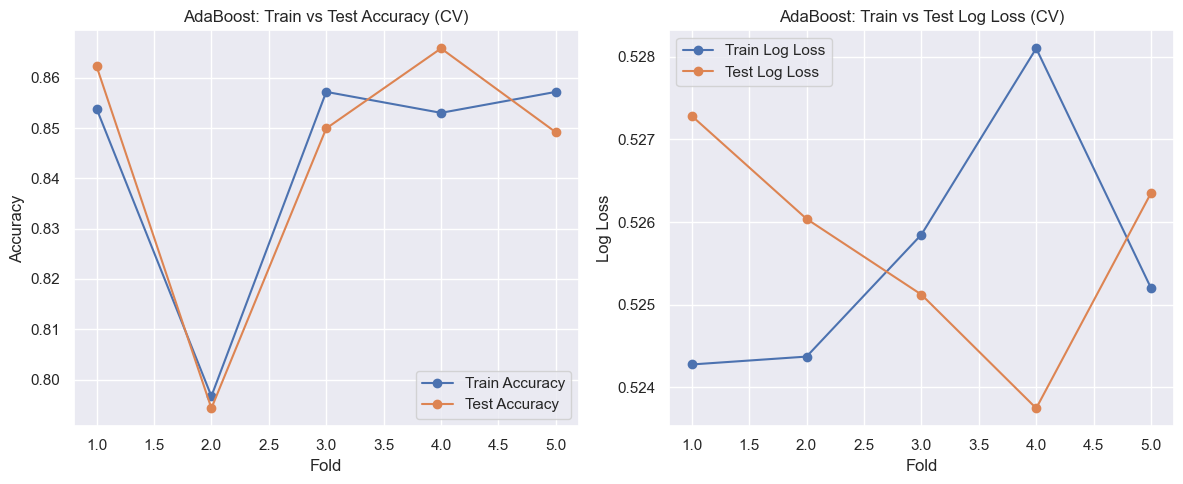

In [37]:
# ================================
# 1. Best parameters from search
# ================================
best_params_ab = {
    'n_estimators': 400,
    'learning_rate': 0.1,
    'random_state': 42
}

# ================================
# 2. Create AdaBoost model
# ================================
ab = AdaBoostClassifier(**best_params_ab)

# ================================
# 3. 5-Fold CV: track accuracy & log loss
# ================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_ab = cross_validate(
    ab,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'neg_log_loss'],
    return_train_score=True
)

# ================================
# 4. CV results
# ================================
train_acc_ab = cv_results_ab['train_accuracy']
test_acc_ab = cv_results_ab['test_accuracy']
train_loss_ab = -cv_results_ab['train_neg_log_loss']
test_loss_ab = -cv_results_ab['test_neg_log_loss']

print(f"\nTrain Acc: {train_acc_ab.mean():.4f} +/- {train_acc_ab.std():.4f}")
print(f"Test Acc: {test_acc_ab.mean():.4f} +/- {test_acc_ab.std():.4f}")
print(f"Train Log Loss: {train_loss_ab.mean():.4f} +/- {train_loss_ab.std():.4f}")
print(f"Test Log Loss: {test_loss_ab.mean():.4f} +/- {test_loss_ab.std():.4f}")

# ================================
# 5. Plot Accuracy & Loss
# ================================
folds = range(1, 6)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(folds, train_acc_ab, label='Train Accuracy', marker='o')
plt.plot(folds, test_acc_ab, label='Test Accuracy', marker='o')
plt.title('AdaBoost: Train vs Test Accuracy (CV)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()

# Log Loss plot
plt.subplot(1, 2, 2)
plt.plot(folds, train_loss_ab, label='Train Log Loss', marker='o')
plt.plot(folds, test_loss_ab, label='Test Log Loss', marker='o')
plt.title('AdaBoost: Train vs Test Log Loss (CV)')
plt.xlabel('Fold')
plt.ylabel('Log Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Model 3 - SVM

Steps:  
1. Hypertuning parameters  
Each model is trained using 5-fold Cross Validation and then performance measure is mean of those results  
2. Printing best results for each measure we want to maximize (as detailed in report)  
3. Printing top 5 accuracy models parameters
4. Plotting 5-fold CV train and test loss and Accuracy comparison to see that there is no overfitting

In [136]:

# ======================================
# Configurable Parameters
# ======================================
params = {
    "C": 1.0,
    "kernels": ["poly", "rbf", "sigmoid"],
    "poly_degrees": [ 3, 5],
    "class_weights": {0: 1, 1: 5},
    "cv_folds": 5,
    "random_state": 42,
}

# ======================================
# Cross-validation setup
# ======================================
cv = KFold(
    n_splits=params["cv_folds"],
    shuffle=True,
    random_state=42
)

# ======================================
# Try Kernels & Degrees with CV
# ======================================
results = []

print(f"\nRunning {params['cv_folds']}-fold CV for poly (degrees={params['poly_degrees']}), rbf, sigmoid...")

# Loop over kernels & degrees if poly
for kernel in tqdm(params["kernels"], desc="Kernel Grid Search"):
    if kernel == "poly":
        for degree in params["poly_degrees"]:
            svm = SVC(
                kernel=kernel,
                degree=degree,
                C=params["C"],
                class_weight=params["class_weights"],
                probability=False,
                random_state=42
            )
            scores_acc = cross_val_score(svm, X_train, y_train, cv=cv, scoring='accuracy')
            scores_precision = cross_val_score(svm, X_train, y_train, cv=cv, scoring='precision')
            scores_recall = cross_val_score(svm, X_train, y_train, cv=cv, scoring='recall')

            results.append({
                'kernel': kernel,
                'degree': degree,
                'mean_cv_accuracy': scores_acc.mean(),
                'mean_cv_precision': scores_precision.mean(),
                'mean_cv_recall': scores_recall.mean()
            })
    else:
        svm = SVC(
            kernel=kernel,
            C=params["C"],
            class_weight=params["class_weights"],
            probability=False,
            random_state=params["random_state"]
        )
        scores_acc = cross_val_score(svm, X_train, y_train, cv=cv, scoring='accuracy')
        scores_precision = cross_val_score(svm, X_train, y_train, cv=cv, scoring='precision')
        scores_recall = cross_val_score(svm, X_train, y_train, cv=cv, scoring='recall')

        results.append({
            'kernel': kernel,
            'degree': None,
            'mean_cv_accuracy': scores_acc.mean(),
            'mean_cv_precision': scores_precision.mean(),
            'mean_cv_recall': scores_recall.mean()
        })

# ======================================
# Find best for each metric
# ======================================
best_acc = max(results, key=lambda x: x['mean_cv_accuracy'])
best_prec = max(results, key=lambda x: x['mean_cv_precision'])
best_recall = max(results, key=lambda x: x['mean_cv_recall'])

print("\nBest for Accuracy:", best_acc)
print("Best for Precision:", best_prec)
print("Best for Recall:", best_recall)

# ======================================
# Final Train & Evaluate for Each Best Model
# ======================================
for metric_name, best_result in zip(
    ['Accuracy', 'Precision', 'Recall'],
    [best_acc, best_prec, best_recall]
):
    print(f"\n========== {metric_name} MODEL ==========")
    if best_result['kernel'] == "poly":
        best_svm = SVC(
            kernel="poly",
            degree=best_result['degree'],
            C=params["C"],
            class_weight=params["class_weights"],
            probability=False,
            random_state=params["random_state"]
        )
    else:
        best_svm = SVC(
            kernel=best_result['kernel'],
            C=params["C"],
            class_weight=params["class_weights"],
            probability=False,
            random_state=params["random_state"]
        )

    best_svm.fit(X_train, y_train)
    y_pred = best_svm.predict(X_test)

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))



Running 5-fold CV for poly (degrees=[3, 5]), rbf, sigmoid...


Kernel Grid Search:   0%|          | 0/3 [00:00<?, ?it/s]


Best for Accuracy: {'kernel': 'poly', 'degree': 3, 'mean_cv_accuracy': np.float64(0.8476806816972055), 'mean_cv_precision': np.float64(0.6356761448105918), 'mean_cv_recall': np.float64(1.0)}
Best for Precision: {'kernel': 'poly', 'degree': 3, 'mean_cv_accuracy': np.float64(0.8476806816972055), 'mean_cv_precision': np.float64(0.6356761448105918), 'mean_cv_recall': np.float64(1.0)}
Best for Recall: {'kernel': 'poly', 'degree': 3, 'mean_cv_accuracy': np.float64(0.8476806816972055), 'mean_cv_precision': np.float64(0.6356761448105918), 'mean_cv_recall': np.float64(1.0)}

========== Accuracy MODEL ==========

Confusion Matrix:
 [[2867  711]
 [   0 1295]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89      3578
           1       0.65      1.00      0.78      1295

    accuracy                           0.85      4873
   macro avg       0.82      0.90      0.84      4873
weighted avg       0.91      0.85      0.86  

(Results analysis is in report of project)


Train Acc: 0.8478 +/- 0.0011
Test Acc: 0.8477 +/- 0.0042
Train Log Loss: 0.2383 +/- 0.0016
Test Log Loss: 0.2833 +/- 0.0060


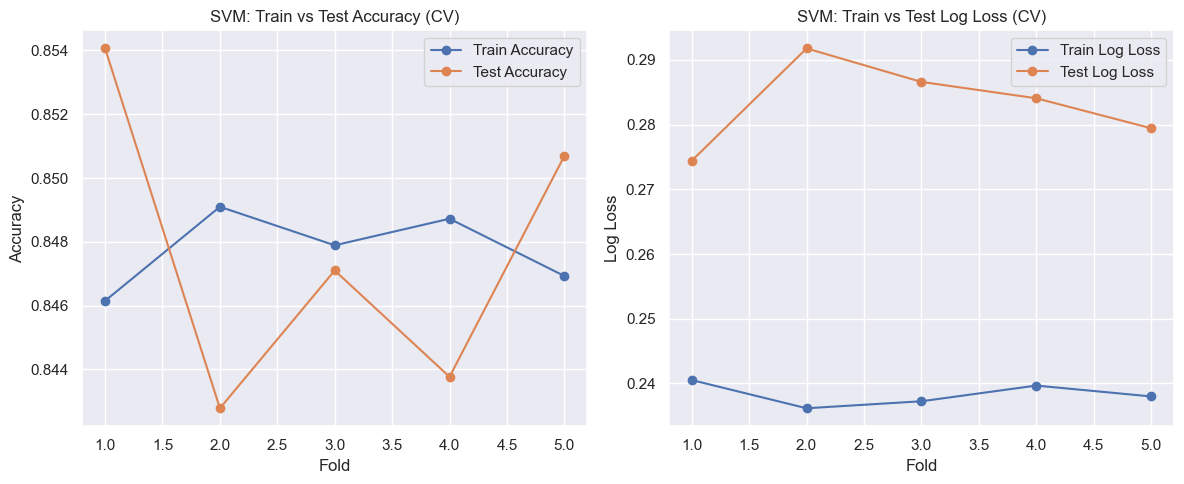

In [60]:
# ================================
# 1. Best SVM parameters (example)
# ================================
best_params_svm = {
    'C': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'random_state': 42
}

# ================================
# 2. Create SVM model
# ================================
svm = SVC(**best_params_svm, probability=True)

# ================================
# 3. 5-Fold CV: track accuracy & log loss
# ================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_svm = cross_validate(
    svm,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'neg_log_loss'],
    return_train_score=True
)

# ================================
# 4. CV results
# ================================
train_acc_svm = cv_results_svm['train_accuracy']
test_acc_svm = cv_results_svm['test_accuracy']
train_loss_svm = -cv_results_svm['train_neg_log_loss']
test_loss_svm = -cv_results_svm['test_neg_log_loss']

print(f"\nTrain Acc: {train_acc_svm.mean():.4f} +/- {train_acc_svm.std():.4f}")
print(f"Test Acc: {test_acc_svm.mean():.4f} +/- {test_acc_svm.std():.4f}")
print(f"Train Log Loss: {train_loss_svm.mean():.4f} +/- {train_loss_svm.std():.4f}")
print(f"Test Log Loss: {test_loss_svm.mean():.4f} +/- {test_loss_svm.std():.4f}")

# ================================
# 5. Plot Accuracy & Loss
# ================================
folds = range(1, 6)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(folds, train_acc_svm, label='Train Accuracy', marker='o')
plt.plot(folds, test_acc_svm, label='Test Accuracy', marker='o')
plt.title('SVM: Train vs Test Accuracy (CV)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()

# Log Loss plot
plt.subplot(1, 2, 2)
plt.plot(folds, train_loss_svm, label='Train Log Loss', marker='o')
plt.plot(folds, test_loss_svm, label='Test Log Loss', marker='o')
plt.title('SVM: Train vs Test Log Loss (CV)')
plt.xlabel('Fold')
plt.ylabel('Log Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Model 4 - XGBoost

Steps:  
1. Hypertuning parameters  
Each model is trained using 5-fold Cross Validation and then performance measure is mean of those results  
2. Printing best results for each measure we want to maximize (as detailed in report)  
3. Printing top 5 accuracy models parameters
4. Plotting 5-fold CV train and test loss and Accuracy comparison to see that there is no overfitting
5. Plotting and extracting the top 10 most important features which helped the model classify

In [121]:


# ===========================================
# Updated Parameter Grid
# ===========================================
param_grid = {
    'n_estimators': [30, 50, 100, 200, 300, 500],
    'max_depth': [5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.001],
    'reg_alpha': [0, 0.05, 0.01],
    'reg_lambda': [1, 2],
}

# ===========================================
# Custom scorers
# ===========================================
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_churn': make_scorer(precision_score, pos_label=1, zero_division=0),
    'recall_churn': make_scorer(recall_score, pos_label=1, zero_division=0)
}

# ===========================================
# Run Manual Grid Search with CV
# ===========================================
param_combinations = list(ParameterGrid(param_grid))
cv_folds = 5

results = []

print(f"Running grid search with {len(param_combinations)} combinations:")

for combo in tqdm(param_combinations, desc="Tuning XGBoost"):
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        **combo
    )
    
    cv_scores = cross_validate(
        model, X_train, y_train,
        scoring=scoring,
        cv=cv_folds,
        n_jobs=-1
    )
    
    results.append({
        'params': combo,
        'accuracy': cv_scores['test_accuracy'].mean(),
        'precision_churn': cv_scores['test_precision_churn'].mean(),
        'recall_churn': cv_scores['test_recall_churn'].mean()
    })

# ===========================================
# Find Best for Each Metric
# ===========================================
best_accuracy = max(results, key=lambda x: x['accuracy'])
best_precision = max(results, key=lambda x: x['precision_churn'])
best_recall = max(results, key=lambda x: x['recall_churn'])

print("\nBest Results from CV:")
print(f"Best Accuracy: {best_accuracy['accuracy']:.4f} with params: {best_accuracy['params']}")
print(f"Best Precision (Churn=1): {best_precision['precision_churn']:.4f} with params: {best_precision['params']}")
print(f"Best Recall (Churn=1): {best_recall['recall_churn']:.4f} with params: {best_recall['params']}")

# ===========================================
# Final Evaluation on Test Set
# ===========================================
for metric_name, best_result in {
    "Accuracy": best_accuracy,
    "Precision (Churn=1)": best_precision,
    "Recall (Churn=1)": best_recall
}.items():
    print(f"\n=== {metric_name} Model ===")
    best_model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        **best_result['params']
    )
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Running grid search with 576 combinations:


Tuning XGBoost:   0%|          | 0/576 [00:00<?, ?it/s]


Best Results from CV:
Best Accuracy: 0.8648 with params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1}
Best Precision (Churn=1): 0.9620 with params: {'learning_rate': 0.001, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 2}
Best Recall (Churn=1): 0.9662 with params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 30, 'reg_alpha': 0.05, 'reg_lambda': 1}

=== Accuracy Model ===


c:\Users\bezzs\anaconda3\envs\lab_2\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:02:49] WARNING: C:\b\abs_52v3kadn8m\croot\xgboost-split_1748343554494\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
 [[3099  479]
 [ 175 1120]]
Classification Report:
               precision    recall  f1-score   support

    No Churn       0.95      0.87      0.90      3578
       Churn       0.70      0.86      0.77      1295

    accuracy                           0.87      4873
   macro avg       0.82      0.87      0.84      4873
weighted avg       0.88      0.87      0.87      4873


=== Precision (Churn=1) Model ===


c:\Users\bezzs\anaconda3\envs\lab_2\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:02:50] WARNING: C:\b\abs_52v3kadn8m\croot\xgboost-split_1748343554494\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
 [[3564   14]
 [ 817  478]]
Classification Report:
               precision    recall  f1-score   support

    No Churn       0.81      1.00      0.90      3578
       Churn       0.97      0.37      0.53      1295

    accuracy                           0.83      4873
   macro avg       0.89      0.68      0.72      4873
weighted avg       0.86      0.83      0.80      4873


=== Recall (Churn=1) Model ===


c:\Users\bezzs\anaconda3\envs\lab_2\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:02:53] WARNING: C:\b\abs_52v3kadn8m\croot\xgboost-split_1748343554494\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
 [[3001  577]
 [  60 1235]]
Classification Report:
               precision    recall  f1-score   support

    No Churn       0.98      0.84      0.90      3578
       Churn       0.68      0.95      0.79      1295

    accuracy                           0.87      4873
   macro avg       0.83      0.90      0.85      4873
weighted avg       0.90      0.87      0.88      4873



(Results analysis is in report of project)

In [127]:
# Sort the results by accuracy in descending order
sorted_results = sorted(results, key=lambda x: x['accuracy'], reverse=True)

# Print the top 10
print("Top 5 Parameter Sets by Accuracy:\n")
for i, res in enumerate(sorted_results[:5], 1):
    print(f"Rank {i}:")
    print(f"Accuracy: {res['accuracy']:.3f}")
    print(f"Params: {res['params']}\n")


Top 5 Parameter Sets by Accuracy:

Rank 1:
Accuracy: 0.865
Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'reg_alpha': 0.01, 'reg_lambda': 1}

Rank 2:
Accuracy: 0.865
Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50, 'reg_alpha': 0.01, 'reg_lambda': 1}

Rank 3:
Accuracy: 0.865
Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50, 'reg_alpha': 0.05, 'reg_lambda': 1}

Rank 4:
Accuracy: 0.865
Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 0.01, 'reg_lambda': 1}

Rank 5:
Accuracy: 0.864
Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 0.01, 'reg_lambda': 2}




Train Acc: 0.8858 +/- 0.0018
Test Acc: 0.8659 +/- 0.0050
Train Log Loss: 0.2100 +/- 0.0010
Test Log Loss: 0.2205 +/- 0.0028


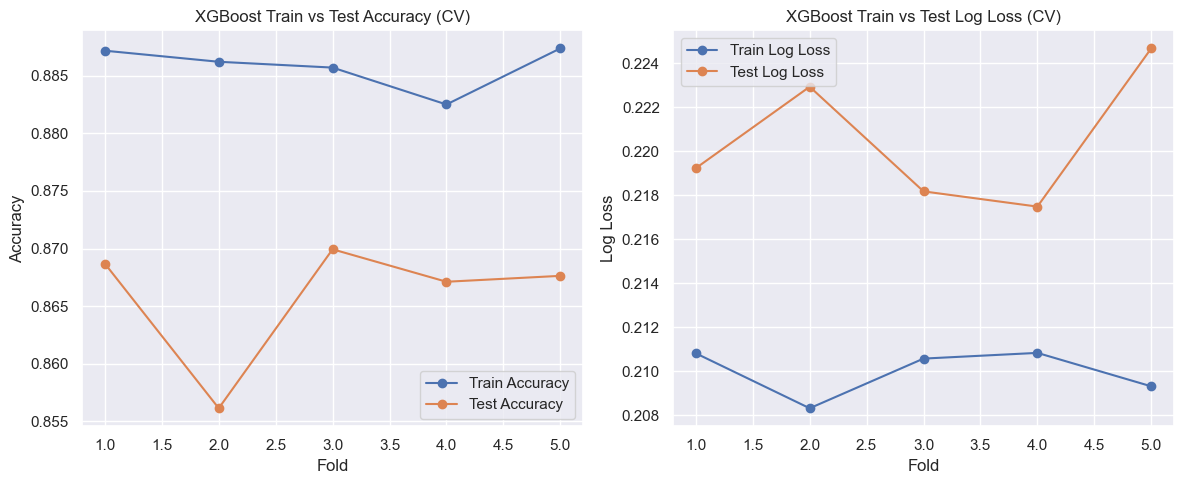


Top 10 XGBoost Features:
membership_category_Silver Membership      0.224348
membership_category_Gold Membership        0.197208
points_in_wallet                           0.160381
membership_category_Premium Membership     0.111610
membership_category_Platinum Membership    0.094473
membership_category_No Membership          0.080637
feedback_kind_Positive                     0.020926
complaint_status_Solved                    0.008151
gender_Male                                0.006482
internet_option_Wi-Fi                      0.005742
dtype: float32


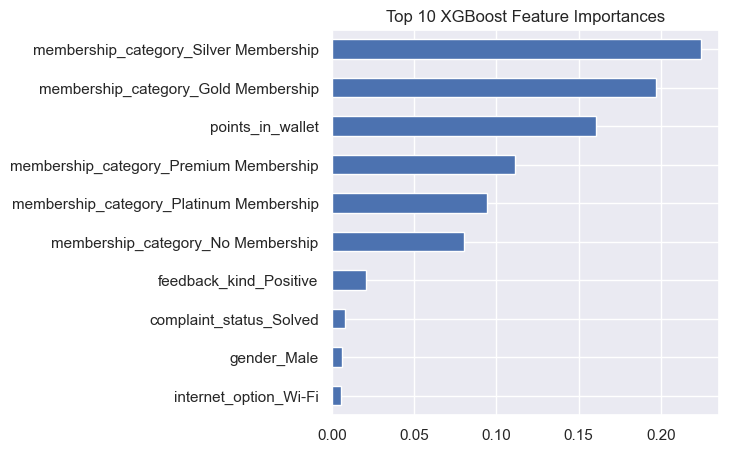

In [134]:
# ================================
# 1. Best hyperparameters
# ================================
xgb_best_params = {
    'learning_rate': 0.05,
    'max_depth': 7,
    'n_estimators': 100,
    'reg_alpha': 0.01,
    'reg_lambda': 1,
    'eval_metric': 'logloss',
    'random_state': 42
}

# ================================
# 2. Create XGBoost model
# ================================
xgb = XGBClassifier(**xgb_best_params)

# ================================
# 3. 5-Fold CV
# ================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'neg_log_loss'],
    return_train_score=True
)

train_acc = cv_results['train_accuracy']
test_acc = cv_results['test_accuracy']
train_loss = -cv_results['train_neg_log_loss']
test_loss = -cv_results['test_neg_log_loss']

print(f"\nTrain Acc: {train_acc.mean():.4f} +/- {train_acc.std():.4f}")
print(f"Test Acc: {test_acc.mean():.4f} +/- {test_acc.std():.4f}")
print(f"Train Log Loss: {train_loss.mean():.4f} +/- {train_loss.std():.4f}")
print(f"Test Log Loss: {test_loss.mean():.4f} +/- {test_loss.std():.4f}")

# ================================
# 4. Plot Accuracy & Log Loss
# ================================
folds = range(1, 6)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(folds, train_acc, label='Train Accuracy', marker='o')
plt.plot(folds, test_acc, label='Test Accuracy', marker='o')
plt.title('XGBoost Train vs Test Accuracy (CV)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()

# Log Loss plot
plt.subplot(1, 2, 2)
plt.plot(folds, train_loss, label='Train Log Loss', marker='o')
plt.plot(folds, test_loss, label='Test Log Loss', marker='o')
plt.title('XGBoost Train vs Test Log Loss (CV)')
plt.xlabel('Fold')
plt.ylabel('Log Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ================================
# 5. Fit final model on all train data
# ================================
xgb.fit(X_train, y_train)

# Predict on test set
y_pred = xgb.predict(X_test)

# ================================
# 6. Top 10 feature importances
# ================================
importances = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 10 XGBoost Features:")
print(importances.head(10))

importances.head(10).plot(kind='barh')
plt.title('Top 10 XGBoost Feature Importances')
plt.gca().invert_yaxis()
plt.show()

# Models Voting

Using voting for 3 models with best parameters for Accuracy:  
Random Forest, Adaboost and XGBoost.  
We train them and then each model votes what to classify each row. Most wins (2 or more vote one way or another)

In [64]:
# =============================
# === 2. Define Models ===
# =============================

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    criterion='entropy',
    class_weight='balanced',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# AdaBoost
ab_model = AdaBoostClassifier(
    n_estimators=400,
    learning_rate=0.1,
    random_state=42
)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.05,
    reg_alpha=0.01,
    reg_lambda=1,
    eval_metric='logloss',
    random_state=42
)

# =============================
# === 3. Train Models ===
# =============================

rf_model.fit(X_train, y_train)
ab_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# =============================
# === 4. Predict on Test ===
# =============================

rf_preds = rf_model.predict(X_test)
ab_preds = ab_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# =============================
# === 5. Majority Vote ===
# =============================

# Stack predictions:
all_preds = np.vstack([rf_preds, ab_preds, xgb_preds]).T

# Majority vote: if sum >= 2 → predict 1
majority_vote_preds = (np.sum(all_preds, axis=1) >= 2).astype(int)

# =============================
# === 6. Evaluate ===
# =============================

print("\n========== VOTING ENSEMBLE RESULTS ==========")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, majority_vote_preds))
print("\nClassification Report:\n", classification_report(y_test, majority_vote_preds))
print(f"Accuracy: {accuracy_score(y_test, majority_vote_preds):.3f}")


# =============================
# === 7. Predict on New Test ===
# =============================

# Get predictions from each base model
rf_test_preds = rf_model.predict(test)
ab_test_preds = ab_model.predict(test)
xgb_test_preds = xgb_model.predict(test)

# Stack predictions
all_test_preds = np.vstack([rf_test_preds, ab_test_preds, xgb_test_preds]).T

# Majority vote: if sum >= 2 → predict 1
majority_vote_test_preds = (np.sum(all_test_preds, axis=1) >= 2).astype(int)

# =============================
# === 8. Save Predictions ===
# =============================



# Create DataFrame
output_df = pd.DataFrame({
    'prediction': majority_vote_test_preds
})

# Save to CSV
output_df.to_csv('test_predictions_Voting_Model.csv', index=False)

print("\nPredictions saved to 'test_predictions_Voting_Model.csv'")




========== VOTING ENSEMBLE RESULTS ==========

Confusion Matrix:
 [[3035  543]
 [  96 1199]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      3578
           1       0.69      0.93      0.79      1295

    accuracy                           0.87      4873
   macro avg       0.83      0.89      0.85      4873
weighted avg       0.89      0.87      0.87      4873

Accuracy: 0.869

Predictions saved to 'test_predictions_Voting_Model.csv'


These are the best results in terms of Accuracy

Checking to make sure output of test works and right shape

In [72]:
output_df.head(10)

,prediction
0,0
1,1
2,1
3,1
4,1
5,1
6,1
7,0
8,0
9,1


In [67]:
output_df.shape

(12208, 1)